<img src="logoucm.png" style="height: 200px">
<center style="color:#888"><br/></center>


<font size="6"><center style="color:#1B4F72"><br/>
Técnicas de Simulación</center></font>
<font size="4"><center style="color:#1B4F72"><br/>
Máster en Ingeniería Matemática</center></font>

<font size="5"><center><span style="color:#117864">***Nombre y Apellidos: Ana Marta Oliveria dos Santos, Mario Queipo Silva y Siria Catherine Iniguez Brito***</span></center></font>

<font size="5"><center><span style="color:#1B4F72">***Práctica 7: Procesos Estocásticos y Caminatas Aleatorias***</span></center></font>

Este notebook introduce los fundamentos de los procesos estocásticos, en particular las caminatas aleatorias, y compara los resultados teóricos con simulaciones realizadas en Python.

### Importamos las librerías necesarias

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

## 1. Introducción a los Procesos Estocásticos

Un **proceso estocástico** es una colección de variables aleatorias indexadas en el tiempo. Estos procesos se utilizan para modelar sistemas que evolucionan aleatoriamente a lo largo del tiempo.

Ejemplos comunes:
- Caminatas aleatorias
- Procesos de Poisson
- Cadenas de Markov

En las prácticas anteriores ya hemos trabajado con un proceso estocástico continuo: el **movimiento browniano**. En esta práctica estudiaremos su antecedente discreto: la **caminata aleatoria**.

## 2. Caminata Aleatoria en 1D

### 2.1 Definición

Una caminata aleatoria en 1 dimensión es una sucesión de pasos hacia adelante (+1) o hacia atrás (−1), decididos aleatoriamente.

### 2.2 Definición Formal

Sea $\{X_i\}_{i=1}^n$ una sucesión de variables aleatorias independientes e idénticamente distribuidas (i.i.d.) tales que:

$$P(X_i = 1) = p, \quad P(X_i = -1) = 1 - p$$

La caminata aleatoria se define como:

$$S_n = \sum_{i=1}^n X_i$$

### 2.3 Esperanza y Varianza

- $E[X_i] = 1 \cdot p + (-1) \cdot (1 - p) = 2p - 1$
- $\text{Var}(X_i) = E[X_i^2] - (E[X_i])^2 = 1 - (2p - 1)^2 = 4p(1 - p)$

Entonces:

$$E[S_n] = n(2p - 1), \quad \text{Var}(S_n) = 4np(1 - p)$$

### 2.4 Relación con el Movimiento Browniano (Principio de Donsker)

Cuando $p = 0.5$, $S_n$ es una suma de variables con esperanza 0 y varianza 1. Por el Teorema Central del Límite:

$$\frac{S_n}{\sqrt{n}} \xrightarrow{d} \mathcal{N}(0,1)$$

Más en general, el **Principio de Invarianza de Donsker** establece que la caminata aleatoria reescalada converge en distribución al proceso de Wiener (movimiento browniano estándar). Esta es la conexión fundamental entre las caminatas aleatorias y el movimiento browniano que hemos simulado en prácticas anteriores.

## 3. Simulación de Caminatas Aleatorias

### 3.1 Caminata aleatoria en 1D (simétrica, p = 0.5)

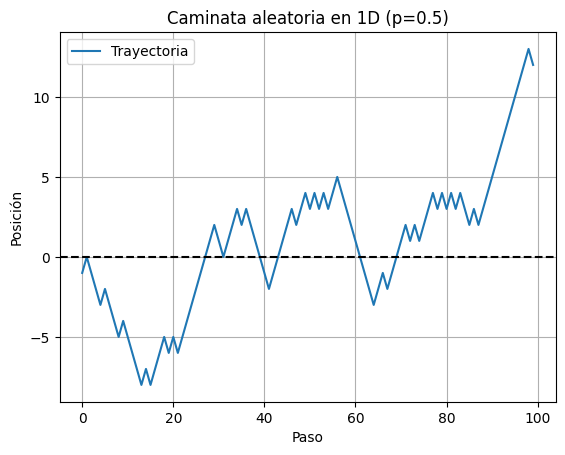

In [3]:
np.random.seed(42)
n = 100
steps = np.random.choice([-1, 1], size=n)
position = np.cumsum(steps)

plt.plot(position, label="Trayectoria")
plt.axhline(0, color='black', linestyle='--')
plt.title("Caminata aleatoria en 1D (p=0.5)")
plt.xlabel("Paso")
plt.ylabel("Posición")
plt.legend()
plt.grid()
plt.show()

Verificamos empíricamente las propiedades teóricas ($E[S_n] = 0$, $\text{Var}(S_n) = n = 100$ para $p = 0.5$):

In [4]:
n_sim = 1000
end_positions = [np.sum(np.random.choice([-1, 1], size=n)) for _ in range(n_sim)]
mean_empirical = np.mean(end_positions)
var_empirical = np.var(end_positions)
mean_theoretical = 0
var_theoretical = n  # 4 * n * p * (1-p) = 4 * 100 * 0.5 * 0.5 = 100

print(f"Media empírica:    {mean_empirical:.4f}")
print(f"Media teórica:     {mean_theoretical}")
print(f"Varianza empírica: {var_empirical:.4f}")
print(f"Varianza teórica:  {var_theoretical}")

Media empírica:    0.1220
Media teórica:     0
Varianza empírica: 100.7491
Varianza teórica:  100


### 3.2 Caminata aleatoria en 2D

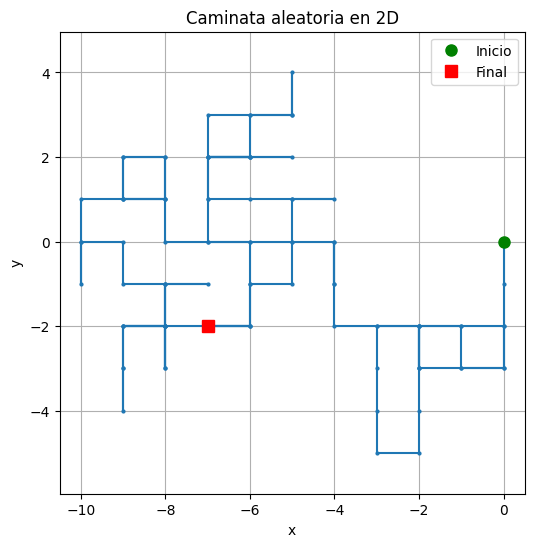

Distancia al origen al final: 7.28
Distancia teórica esperada (√n): 10.00


In [5]:
directions = [(1,0), (-1,0), (0,1), (0,-1)]
position_2d = np.zeros((n, 2))
for i in range(1, n):
    move = directions[np.random.randint(4)]
    position_2d[i] = position_2d[i-1] + move

plt.figure(figsize=(6,6))
plt.plot(position_2d[:,0], position_2d[:,1], marker='o', markersize=2)
plt.plot(0, 0, 'go', markersize=8, label='Inicio')
plt.plot(position_2d[-1,0], position_2d[-1,1], 'rs', markersize=8, label='Final')
plt.title("Caminata aleatoria en 2D")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.axis('equal')
plt.show()

distancia_final = np.linalg.norm(position_2d[-1])
print(f"Distancia al origen al final: {distancia_final:.2f}")
print(f"Distancia teórica esperada (√n): {np.sqrt(n):.2f}")

### 3.3 Caminata con probabilidad sesgada (p ≠ 0.5)

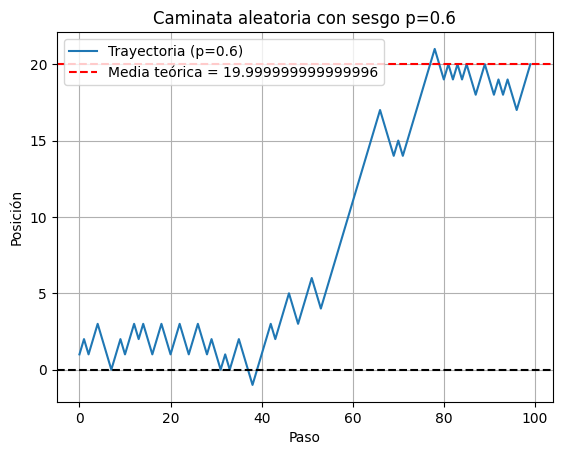

Media teórica E[S_n] = n(2p-1) = 19.999999999999996
Varianza teórica Var(S_n) = 4np(1-p) = 96.0


In [6]:
p = 0.6
steps_sesgada = np.random.choice([-1, 1], size=n, p=[1-p, p])
position_sesgada = np.cumsum(steps_sesgada)

mean_theoretical_sesgada = n * (2*p - 1)
var_theoretical_sesgada = 4 * n * p * (1-p)

plt.plot(position_sesgada, label=f"Trayectoria (p={p})")
plt.axhline(0, color='black', linestyle='--')
plt.axhline(mean_theoretical_sesgada, color='red', linestyle='--',
            label=f"Media teórica = {mean_theoretical_sesgada}")
plt.title(f"Caminata aleatoria con sesgo p={p}")
plt.xlabel("Paso")
plt.ylabel("Posición")
plt.legend()
plt.grid()
plt.show()

print(f"Media teórica E[S_n] = n(2p-1) = {mean_theoretical_sesgada}")
print(f"Varianza teórica Var(S_n) = 4np(1-p) = {var_theoretical_sesgada}")

## 4. Ejercicio 1: Proporción de veces que termina cerca del origen

### 📌 Enunciado
Simula 1000 caminatas de 100 pasos con $p = 0.5$. ¿Qué proporción de veces termina a menos de 10 unidades del origen?

**Resultado teórico:** Dado que $S_n \sim \mathcal{N}(0, n)$ aproximadamente, la probabilidad teórica es:

$$P(-10 < S_n < 10) \approx P\left(\frac{-10}{\sqrt{n}} < Z < \frac{10}{\sqrt{n}}\right) = \Phi\left(\frac{10}{\sqrt{n}}\right) - \Phi\left(\frac{-10}{\sqrt{n}}\right)$$

--- Resultados del Ejercicio ---
Proporción simulada (empírica): 0.6300
Probabilidad teórica (TCL):     0.6827
Diferencia:                     0.0526


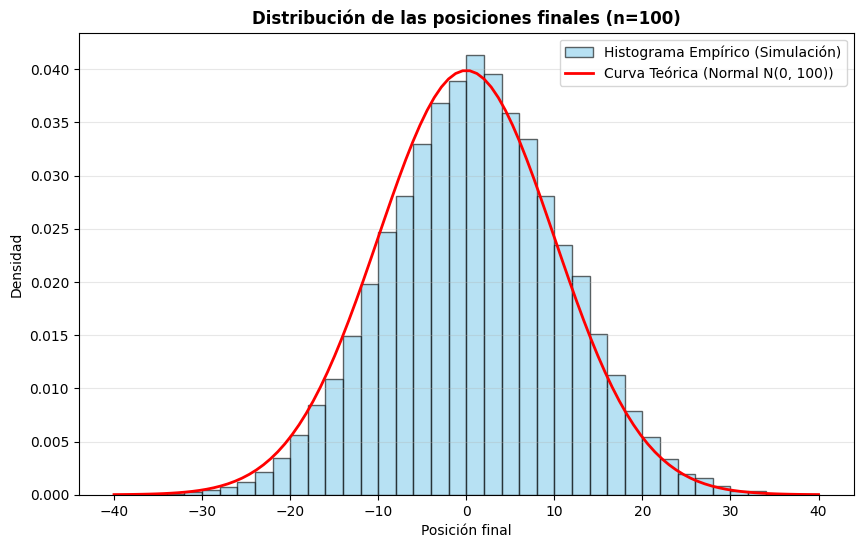

In [21]:
# ==========================================
# 1. Simulación de la Caminata Aleatoria
# ==========================================

# Fijamos la semilla para que los resultados sean reproducibles
np.random.seed(42)

n_simulaciones = 50000  # Número de caminatas
n_pasos = 100           # Pasos por caminata
p = 0.5                 # Probabilidad de dar un paso hacia adelante (+1)

# Simulamos los pasos: matriz de 50000 filas (caminatas) x 100 columnas (pasos)
# Elige aleatoriamente -1 o 1
pasos = np.random.choice([-1, 1], size=(n_simulaciones, n_pasos))

# La posición final de cada caminata es la suma de todos sus pasos
posiciones_finales = np.sum(pasos, axis=1)

# Calculamos la proporción de veces que termina a menos de 10 unidades del origen
# Es decir, -10 < S_n < 10  (o lo que es lo mismo, |S_n| < 10)
exitos = np.sum((posiciones_finales > -10) & (posiciones_finales < 10))
proporcion_simulada = exitos / n_simulaciones

# ==========================================
# 2. Resultado Teórico (Aproximación Normal)
# ==========================================

# Según el Teorema Central del Límite: S_n ~ N(0, n)
# Queremos calcular P(-10 < S_n < 10)
limite_superior = 10 / np.sqrt(n_pasos)
limite_inferior = -10 / np.sqrt(n_pasos)

# Usamos la función de distribución acumulada (cdf) de la normal estándar
probabilidad_teorica = norm.cdf(limite_superior) - norm.cdf(limite_inferior)

# ==========================================
# 3. Comparación de Resultados
# ==========================================

print(f"--- Resultados del Ejercicio ---")
print(f"Proporción simulada (empírica): {proporcion_simulada:.4f}")
print(f"Probabilidad teórica (TCL):     {probabilidad_teorica:.4f}")
print(f"Diferencia:                     {abs(proporcion_simulada - probabilidad_teorica):.4f}")

# ==========================================
# 4. Visualización: Histograma en el paso 100
# ==========================================

plt.figure(figsize=(10, 6))

# Dibujamos el histograma de las posiciones finales
plt.hist(posiciones_finales, bins=range(-40, 42, 2), density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histograma Empírico (Simulación)')

# Superponemos la curva teórica de la Normal

# Definimos el rango del eje X para la curva teórica
x = np.linspace(-40, 40, 100)
# La desviación estándar de S_n es sqrt(n) = 10
std_dev = np.sqrt(n_pasos)
# Calculamos la PDF de la normal N(0, 10^2)
pdf = stats.norm.pdf(x, 0, std_dev)

# Dibujamos la curva teórica
plt.plot(x, pdf, 'r-', lw=2, label='Curva Teórica (Normal N(0, 100))')

# Añadimos detalles al gráfico
plt.title(f'Distribución de las posiciones finales (n={n_pasos})', fontweight='bold')
plt.xlabel('Posición final')
plt.ylabel('Densidad')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostramos el gráfico
plt.show()


## 5. Ejercicio 2: Distancia media al origen en 2D

### 📌 Enunciado
Simula 100 caminatas en 2D de 200 pasos y calcula la distancia promedio al origen al final de cada caminata.

**Resultado teórico:** En 2D, la caminata aleatoria con pasos de longitud 1 tiene distancia cuadrática media $E[\|X_n\|^2] = n$, por lo tanto:

$$E[\|X_n\|] \approx \sqrt{n}$$

En este caso $\sqrt{200} \approx 14.1$

--- Resultados del Ejercicio 2 (Caminata 2D) ---
Distancia media simulada (100 caminatas): 12.8460
Distancia media teórica (sqrt(200)):      14.1421
Diferencia absoluta:                      1.2962


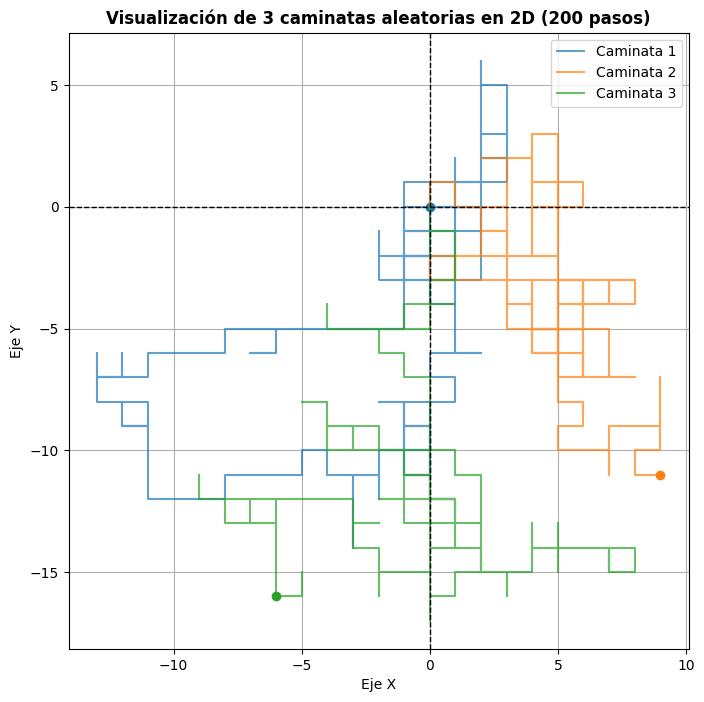

In [22]:
# ==========================================
# 1. Parámetros de la simulación
# ==========================================
np.random.seed(42)    # Semilla para reproducibilidad

n_simulaciones = 100  # Número de caminatas
n_pasos = 200         # Pasos por caminata

# Las 4 direcciones posibles en 2D: (x, y)
# Derecha, Izquierda, Arriba, Abajo
direcciones = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]])

# ==========================================
# 2. Simulación de las Caminatas en 2D
# ==========================================
# Generamos índices aleatorios (0, 1, 2 o 3) para cada paso de cada simulación
# Matriz: 100 filas (caminatas) x 200 columnas (pasos)
indices_movimientos = np.random.randint(0, 4, size=(n_simulaciones, n_pasos))

# Mapeamos los índices a los vectores de dirección reales
# 'pasos' será un array 3D de tamaño (100, 200, 2)
pasos = direcciones[indices_movimientos]

# Sumamos todos los pasos de cada caminata (a lo largo del eje 1) para obtener la posición final
# Resultado: array de tamaño (100, 2) con las coordenadas (x, y) finales
posiciones_finales = np.sum(pasos, axis=1)

# ==========================================
# 3. Cálculo de Distancias
# ==========================================
# Calculamos la distancia euclidiana al origen (0,0) para cada posición final
# La norma vectorial de [x, y] es sqrt(x^2 + y^2)
distancias = np.linalg.norm(posiciones_finales, axis=1)

# Calculamos la distancia promedio de las 100 simulaciones
distancia_media_simulada = np.mean(distancias)

# ==========================================
# 4. Resultado Teórico y Comparación
# ==========================================
# En 2D, la distancia esperada es aproximadamente la raíz cuadrada del número de pasos
distancia_teorica = np.sqrt(n_pasos)

print("--- Resultados del Ejercicio 2 (Caminata 2D) ---")
print(f"Distancia media simulada (100 caminatas): {distancia_media_simulada:.4f}")
print(f"Distancia media teórica (sqrt(200)):      {distancia_teorica:.4f}")
print(f"Diferencia absoluta:                      {abs(distancia_media_simulada - distancia_teorica):.4f}")

# ==========================================
# 5. Visualización
# ==========================================
plt.figure(figsize=(8, 8))

# Graficamos las primeras 3 caminatas
for i in range(3):
    # Obtenemos la trayectoria acumulada:
    # pasos[i] es una matriz (200, 2), cumsum nos da la posición en cada instante
    trayectoria = np.cumsum(pasos[i], axis=0)

    # Añadimos un origen [0,0] al principio para el gráfico
    trayectoria = np.vstack([[0, 0], trayectoria])

    plt.plot(trayectoria[:, 0], trayectoria[:, 1], alpha=0.7, label=f'Caminata {i+1}')
    plt.scatter(trayectoria[-1, 0], trayectoria[-1, 1], marker='o') # Punto final

plt.title(f'Visualización de 3 caminatas aleatorias en 2D ({n_pasos} pasos)', fontweight='bold')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.axhline(0, color='black', lw=1, ls='--')
plt.axvline(0, color='black', lw=1, ls='--')
plt.legend()
plt.grid(True)
plt.show()



### **Ejercicio Extra:** Demostración Empírica: Recurrencia en 1D y 2D vs. Transitoriedad en 3D


--- Resultados en el paso 2000 ---
Probabilidad empírica 1D: 98.40%
Probabilidad empírica 2D: 70.73%
Probabilidad empírica 3D: 34.40%


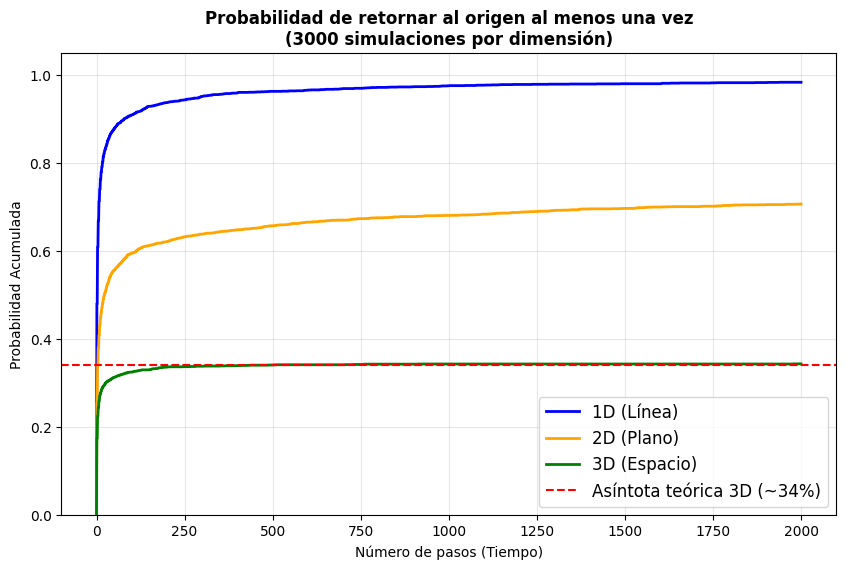

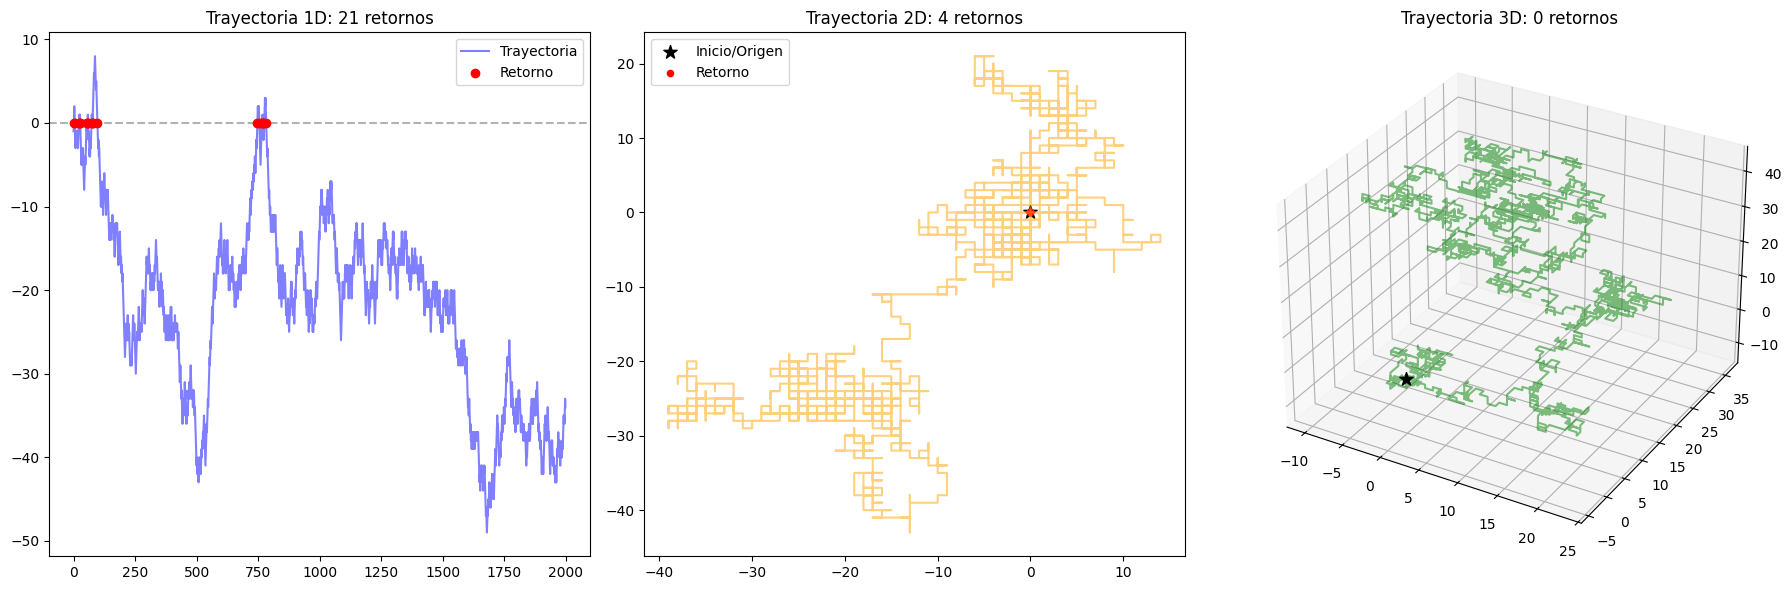

In [28]:
# ==========================================
# 1. Configuración de la Simulación
# ==========================================
np.random.seed(42)

n_simulaciones = 3000  # Número de caminatas a simular por dimensión
n_pasos = 2000         # Número de pasos que dará cada caminata

def probabilidad_acumulada_retorno(dim, n_sims, n_pasos):
    """
    Simula caminatas aleatorias y devuelve un array con la proporción
    de caminatas que han retornado al origen al menos una vez en cada paso.
    """
    if dim == 1:
        # 2 direcciones: izquierda, derecha
        pasos = np.random.choice([-1, 1], size=(n_sims, n_pasos, 1))

    elif dim == 2:
        # 4 direcciones: N, S, E, O
        direcciones = np.array([[1,0], [-1,0], [0,1], [0,-1]])
        pasos = direcciones[np.random.randint(0, 4, size=(n_sims, n_pasos))]

    elif dim == 3:
        # 6 direcciones: N, S, E, O, Arriba, Abajo
        direcciones = np.array([[1,0,0], [-1,0,0], [0,1,0], [0,-1,0], [0,0,1], [0,0,-1]])
        pasos = direcciones[np.random.randint(0, 6, size=(n_sims, n_pasos))]

    # Suma acumulada para obtener las coordenadas en cada instante
    posiciones = np.cumsum(pasos, axis=1)

    # Calculamos la suma absoluta de las coordenadas (Distancia Manhattan)
    # Si la suma es 0, significa que la posición exacta es el origen (0) o (0,0) o (0,0,0)
    distancias_al_origen = np.sum(np.abs(posiciones), axis=-1)

    # Matriz booleana: True si en ese paso exacto está en el origen
    en_origen = (distancias_al_origen == 0)

    # Acumulamos lógicamente (OR): True si ha estado en el origen en algún paso anterior
    ha_retornado_alguna_vez = np.maximum.accumulate(en_origen, axis=1)

    # Calculamos la proporción (promedio) de caminatas que han retornado para cada paso
    proporcion_acumulada = np.mean(ha_retornado_alguna_vez, axis=0)

    return proporcion_acumulada

# ==========================================
# 2. Ejecución y Cálculo
# ==========================================
prob_1d = probabilidad_acumulada_retorno(1, n_simulaciones, n_pasos)

prob_2d = probabilidad_acumulada_retorno(2, n_simulaciones, n_pasos)

prob_3d = probabilidad_acumulada_retorno(3, n_simulaciones, n_pasos)

# ==========================================
# 3. Visualización
# ==========================================
print("\n--- Resultados en el paso", n_pasos, "---")
print(f"Probabilidad empírica 1D: {prob_1d[-1]:.2%}")
print(f"Probabilidad empírica 2D: {prob_2d[-1]:.2%}")
print(f"Probabilidad empírica 3D: {prob_3d[-1]:.2%}")

plt.figure(figsize=(10, 6))

plt.plot(prob_1d, label='1D (Línea)', color='blue', linewidth=2)
plt.plot(prob_2d, label='2D (Plano)', color='orange', linewidth=2)
plt.plot(prob_3d, label='3D (Espacio)', color='green', linewidth=2)

# Añadimos la asíntota teórica de Pólya para 3D (~0.3405)
plt.axhline(y=0.3405, color='red', linestyle='--', label='Asíntota teórica 3D (~34%)')

plt.title(f"Probabilidad de retornar al origen al menos una vez\n({n_simulaciones} simulaciones por dimensión)", fontweight='bold')
plt.xlabel("Número de pasos (Tiempo)")
plt.ylabel("Probabilidad Acumulada")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right', fontsize=12)

plt.show()


fig = plt.figure(figsize=(18, 6))

# --- 1D: Marcando retornos ---
ax1 = fig.add_subplot(131)
pos_1d = np.cumsum(np.random.choice([-1, 1], size=n_pasos))
ax1.plot(pos_1d, color='blue', alpha=0.5, label='Trayectoria')
ax1.axhline(0, color='black', linestyle='--', alpha=0.3)
# Identificar retornos
retornos_1d = np.where(pos_1d == 0)[0]
ax1.scatter(retornos_1d, np.zeros_like(retornos_1d), color='red', zorder=5, label='Retorno')
ax1.set_title(f"Trayectoria 1D: {len(retornos_1d)} retornos")
ax1.legend()

# --- 2D: Marcando retornos ---
ax2 = fig.add_subplot(132)
direcciones_2d = np.array([[1,0], [-1,0], [0,1], [0,-1]])
pos_2d = np.cumsum(direcciones_2d[np.random.randint(0, 4, n_pasos)], axis=0)
ax2.plot(pos_2d[:, 0], pos_2d[:, 1], color='orange', alpha=0.5)
ax2.scatter(0, 0, color='black', s=100, marker='*', label='Inicio/Origen')
# Identificar retornos
retornos_2d = np.where(np.all(pos_2d == 0, axis=1))[0]
ax2.scatter(pos_2d[retornos_2d, 0], pos_2d[retornos_2d, 1], color='red', s=20, label='Retorno')
ax2.set_title(f"Trayectoria 2D: {len(retornos_2d)} retornos")
ax2.legend()

# --- 3D: Marcando retornos ---
ax3 = fig.add_subplot(133, projection='3d')
direcciones_3d = np.array([[1,0,0], [-1,0,0], [0,1,0], [0,-1,0], [0,0,1], [0,0,-1]])
pos_3d = np.cumsum(direcciones_3d[np.random.randint(0, 6, n_pasos)], axis=0)
ax3.plot(pos_3d[:, 0], pos_3d[:, 1], pos_3d[:, 2], color='green', alpha=0.5)
ax3.scatter(0, 0, 0, color='black', s=100, marker='*')

# Identificar retornos
retornos_3d = np.where(np.all(pos_3d == 0, axis=1))[0]
ax3.scatter(pos_3d[retornos_3d, 0], pos_3d[retornos_3d, 1], pos_3d[retornos_3d, 2], color='red', s=30, label='Retorno')
ax3.set_title(f"Trayectoria 3D: {len(retornos_3d)} retornos")

plt.tight_layout()
plt.show()

### Análisis de la Recurrencia en Caminatas Aleatorias

La probabilidad de que una caminata aleatoria regrese al origen depende de los grados de libertad disponibles. En nuestro estudio, hemos analizado 3000 simulaciones independientes de 2000 pasos cada una; el valor de **"Probabilidad de Retorno"** que presentamos representa la fracción de estas simulaciones en las que el caminante logró tocar el origen $(0,0,0...)$ al menos una vez durante su recorrido.

Nuestros resultados empíricos tras 2000 pasos son los siguientes:

| Dimensión | Probabilidad de Retorno (al menos una vez) |
| :--- | :--- |
| **1D (Línea)** | **98.40%** |
| **2D (Plano)** | **70.73%** |
| **3D (Espacio)** | **34.40%** |

#### Interpretación de los resultados:

* **En 1D:** Con solo dos direcciones posibles, el espacio de exploración es muy limitado. El caminante cruza el origen de forma recurrente debido a que las restricciones de movimiento lo obligan a "revisitar" su trayectoria. . Si se aleja del origen, la única forma de seguir explorando el espacio origen es alejándose infinitamente en una dirección exacta, lo cual es casi imposible. Esto explica por qué el **98.40%** de las simulaciones regresaron al origen: en una dimensión, el retorno no es una posibilidad, sino una consecuencia casi inevitable.

* **En 2D:** Al aumentar a cuatro direcciones, el caminante gana libertad y el área de exploración crece de forma lineal. Sin embargo, este crecimiento es lo suficientemente lento como para que el caminante "barra" el plano de manera densa, acumulándose cerca del centro. Esto permite que un **70.73%** de los caminantes encuentren el origen, manteniendo una alta recurrencia.

* **En 3D:** Con seis direcciones disponibles, el volumen del espacio crece de forma cúbica. La cantidad de rutas posibles es tan vasta que la probabilidad de que todas las coordenadas sean cero simultáneamente se vuelve remota. El resultado del **34.40%** confirma empíricamente la asíntota teórica de Pólya; es decir, la mayoría de los caminantes (cerca de un 66%) se perderán en el infinito sin haber regresado nunca al origen.

En conclusión, los datos validan la transición de un comportamiento **recurrente** en 1D y 2D, hacia un comportamiento **transitorio** en 3D. Mientras que en las dimensiones inferiores el retorno es una propiedad inherente de la caminata, en 3D se tiene una probabilidad mayor al 60% de no regresar jamás.

## 6. Ejercicio 3: Efecto del sesgo en la media final

### 📌 Enunciado
Simula 1000 caminatas de 100 pasos para distintos valores del sesgo $p \in \{0.5, 0.6, 0.7, 0.8\}$. Representa gráficamente la media empírica de la posición final frente al valor teórico $E[S_n] = n(2p - 1)$.

**Resultado teórico:** La media esperada al paso $n$ es $E[S_n] = n(2p - 1)$, función lineal de $p$.

--- Calculando medias para distintos sesgos ---
p = 0.5: Media empírica = 0.13 | Media teórica = 0.00
p = 0.6: Media empírica = 20.31 | Media teórica = 20.00
p = 0.7: Media empírica = 40.12 | Media teórica = 40.00
p = 0.8: Media empírica = 60.09 | Media teórica = 60.00


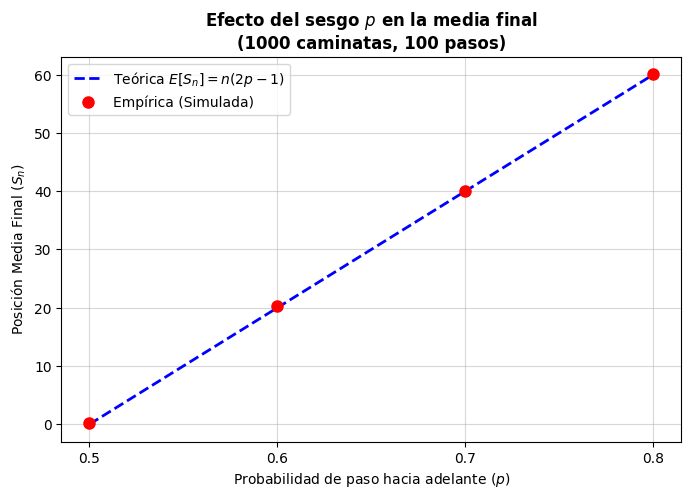

In [29]:
# ==========================================
# 1. Parámetros de la simulación
# ==========================================
np.random.seed(42)

n_simulaciones = 1000  # Número de caminatas por cada p
n_pasos = 100          # Pasos por caminata
valores_p = [0.5, 0.6, 0.7, 0.8]  # Valores de probabilidad (sesgo)

# Listas para guardar los resultados y graficarlos luego
medias_empiricas = []
medias_teoricas = []

# ==========================================
# 2. Simulación para cada valor de p
# ==========================================
print("--- Calculando medias para distintos sesgos ---")

for p in valores_p:
    # Probabilidad de ir hacia atrás (-1) es 1 - p
    probabilidades = [1 - p, p]

    # Simulamos las caminatas
    # Usamos el parámetro 'p' en np.random.choice para aplicar el sesgo
    pasos = np.random.choice([-1, 1], size=(n_simulaciones, n_pasos), p=probabilidades)

    # Calculamos la posición final de cada una de las 1000 caminatas
    posiciones_finales = np.sum(pasos, axis=1)

    # Calculamos la media empírica (promedio de las posiciones finales simuladas)
    media_empirica = np.mean(posiciones_finales)
    medias_empiricas.append(media_empirica)

    # Calculamos la media teórica según la fórmula E[S_n] = n(2p - 1)
    media_teorica = n_pasos * (2 * p - 1)
    medias_teoricas.append(media_teorica)

    print(f"p = {p}: Media empírica = {media_empirica:.2f} | Media teórica = {media_teorica:.2f}")

# ==========================================
# 3. Representación Gráfica
# ==========================================
plt.figure(figsize=(8, 5))

# Trazamos la línea teórica
plt.plot(valores_p, medias_teoricas, label='Teórica $E[S_n] = n(2p - 1)$',
         color='blue', linestyle='--', linewidth=2)

# Añadimos los puntos exactos de la simulación empírica
plt.plot(valores_p, medias_empiricas, label='Empírica (Simulada)',
         color='red', marker='o', markersize=8, linestyle='')

# Configuramos la gráfica
plt.title(f"Efecto del sesgo $p$ en la media final\n({n_simulaciones} caminatas, {n_pasos} pasos)", fontweight='bold')
plt.xlabel("Probabilidad de paso hacia adelante ($p$)")
plt.ylabel("Posición Media Final ($S_n$)")
plt.xticks(valores_p)
plt.legend()
plt.grid(True, alpha=0.5)

# Mostramos el resultado
plt.show()

#### Observaciones clave:
* **Relación Lineal:** La gráfica confirma que la posición media final es una función estrictamente lineal de la probabilidad de sesgo $p$. Esto es consistente con el hecho de que, en cada paso, el desplazamiento esperado es $(1 \cdot p) + (-1 \cdot (1-p)) = 2p - 1$. Al sumar $n$ pasos independientes, la linealidad se mantiene.
* **Comportamiento en $p=0.5$:** Para un sesgo nulo ($p=0.5$), el valor teórico es $0$. Nuestra media empírica de **0.13** confirma que, en caminatas simétricas, la posición final tiende a distribuirse equilibradamente alrededor del origen.
* **Efecto de "Arrastre" ($p > 0.5$):** A medida que $p$ se incrementa, observamos cómo el caminante es sistemáticamente "empujado" hacia la derecha. Por ejemplo, con $p=0.8$, la media esperada de **60** es similar a la media emprírica en nuestra simulación (**60.09**).
* **Robustez estadística:** La pequeña discrepancia entre los valores teóricos y empíricos confirma que, con $1000$ simulaciones, hemos alcanzado una convergencia estadística muy alta.


## 7. Ejercicio 4: Caminata aleatoria como Cadena de Markov

### 📌 Enunciado
La caminata aleatoria es un caso particular de cadena de Markov en tiempo discreto con espacio de estados $\mathbb{Z}$.

1. Escribe las probabilidades de transición $P_{ij}$ de la caminata aleatoria simétrica ($p = 0.5$).

2. Muestra que la caminata verifica la propiedad markoviana: dado el estado actual $S_n$, el futuro $S_{n+1}, S_{n+2}, \ldots$ es independiente del pasado $S_{n-1}, S_{n-2}, \ldots, S_0$.

3. Simula 500 pasos de la caminata con $p = 0.5$ y representa gráficamente la distribución de posiciones en los instantes $t = 10, 50, 100, 500$. ¿Qué observas?

## 8. Conclusiones

- Las caminatas aleatorias son modelos discretos sencillos pero poderosos para modelar procesos estocásticos.
- Las simulaciones permiten validar las propiedades teóricas de estos procesos.
- La concordancia entre teoría y práctica mejora al aumentar el número de simulaciones.
- La caminata aleatoria es un caso particular de cadena de Markov, lo que establece el puente conceptual con los modelos que estudiaremos en el siguiente bloque del curso.
- Por el Principio de Invarianza de Donsker, la caminata aleatoria reescalada converge al movimiento browniano, conectando así con el bloque de opciones financieras.